# Astro 416 Final Project - Kaj Desch #

## Imported Packages ##

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn import metrics

import itertools #discovered with AI

## Reading in the Data ##

In [2]:
df_candidates = pd.read_csv("TESS_exoplanet_candidates.csv")
df_candidates.columns

Index(['rowid', 'toi', 'toipfx', 'tid', 'ctoi_alias', 'pl_pnum', 'tfopwg_disp',
       'rastr', 'ra', 'raerr1', 'raerr2', 'decstr', 'dec', 'decerr1',
       'decerr2', 'st_pmra', 'st_pmraerr1', 'st_pmraerr2', 'st_pmralim',
       'st_pmrasymerr', 'st_pmdec', 'st_pmdecerr1', 'st_pmdecerr2',
       'st_pmdeclim', 'st_pmdecsymerr', 'pl_tranmid', 'pl_tranmiderr1',
       'pl_tranmiderr2', 'pl_tranmidlim', 'pl_tranmidsymerr', 'pl_orbper',
       'pl_orbpererr1', 'pl_orbpererr2', 'pl_orbperlim', 'pl_orbpersymerr',
       'pl_trandurh', 'pl_trandurherr1', 'pl_trandurherr2', 'pl_trandurhlim',
       'pl_trandurhsymerr', 'pl_trandep', 'pl_trandeperr1', 'pl_trandeperr2',
       'pl_trandeplim', 'pl_trandepsymerr', 'pl_rade', 'pl_radeerr1',
       'pl_radeerr2', 'pl_radelim', 'pl_radesymerr', 'pl_insol',
       'pl_insolerr1', 'pl_insolerr2', 'pl_insollim', 'pl_insolsymerr',
       'pl_eqt', 'pl_eqterr1', 'pl_eqterr2', 'pl_eqtlim', 'pl_eqtsymerr',
       'st_tmag', 'st_tmagerr1', 'st_tmagerr2', '

In [3]:
df_planets = pd.read_csv("confirmed_exoplanets.csv")
df_planets.columns

Index(['pl_name', 'hostname', 'pl_letter', 'hd_name', 'hip_name', 'tic_id',
       'gaia_id', 'default_flag', 'sy_snum', 'sy_pnum',
       ...
       'rowupdate', 'pl_pubdate', 'releasedate', 'pl_nnotes', 'st_nphot',
       'st_nrvc', 'st_nspec', 'pl_nespec', 'pl_ntranspec', 'pl_ndispec'],
      dtype='object', length=287)

## Setting up the Data ##

In [4]:
# Note: This cell's functions were created with the help of ChatGPT.

# Function to check if there's a planet match within tolerance
def is_planet_match(row, df_planets, tolerance):
    ra_match = np.abs(df_planets['ra'] - row['ra']) <= tolerance 
    dec_match = np.abs(df_planets['dec'] - row['dec']) <= tolerance
    # Checking the ra and dec to determine if any of the candidates have the same ra and dec as a confirmed exoplanet
    return (ra_match & dec_match).any()
    # If the coordinates match with any confirmed exoplanet, we can reasonably infer that this candidate is an exoplanet.
    # Returns a true/false value.

tolerance = 0.002 #Setting a very small tolerance value in case there is a tiny discrepancy between datasets.

df_candidates['is_planet'] = df_candidates.apply(
    lambda row: is_planet_match(row, df_planets, tolerance), axis=1
)
# Creating a new boolean column in the candidates dataframe marking whether or not it is a confirmed exoplanet.

In [5]:
print(df_candidates['is_planet'].value_counts())
# Note: We will not use every candidate due to some N/A values in certain rows. Those rows are dropped. 
# This is just for confirmation that our marking process worked.

is_planet
False    6895
True      630
Name: count, dtype: int64


In [6]:
df_candidates.head

<bound method NDFrame.head of       rowid      toi  toipfx        tid    ctoi_alias  pl_pnum tfopwg_disp  \
0         1  1000.01    1000   50365310  5.036531e+07        1          FP   
1         2  1001.01    1001   88863718  8.886372e+07        1          PC   
2         3  1002.01    1002  124709665  1.247097e+08        1          FP   
3         4  1003.01    1003  106997505  1.069975e+08        1          FP   
4         5  1004.01    1004  238597883  2.385979e+08        1          FP   
...     ...      ...     ...        ...           ...      ...         ...   
7520   7521   995.01     995  317951248  3.179512e+08        1          FP   
7521   7522   996.01     996  142918609  1.429186e+08        1          FP   
7522   7523   997.01     997  341729521  3.417295e+08        1          FP   
7523   7524   998.01     998   54390047  5.439005e+07        1          FP   
7524   7525   999.01     999  341186896  3.411869e+08        1          FP   

             rastr          ra  r

## Machine Learning ##

In [7]:
LearningSet = df_candidates[['pl_orbper', 'pl_trandurh', 'pl_trandep', 'pl_rade', 'pl_eqt', 'st_dist','is_planet']].dropna()
# Setting up the learning set with any potential features, along with our target parameter 'is_planet'
# We drop all planets that have na values.

TrainSet =  LearningSet.iloc[:5348,:]  
TestSet = LearningSet.iloc[5348:,:]
# Setting up the training (80%) and testing (20%) sets,

LearningSet

,pl_orbper,pl_trandurh,pl_trandep,pl_rade,pl_eqt,st_dist,is_planet
0,2.171348,2.017220,656.886099,5.818163,3127.204052,485.735,False
1,1.931646,3.166000,1286.000000,11.215400,4045.000000,295.862,False
2,1.867557,1.408000,1500.000000,23.752900,2037.000000,943.109,False
4,3.573014,3.370000,755.000000,11.311300,4260.000000,356.437,False
5,4.550720,2.599000,3620.000000,6.544490,1112.000000,100.711,False
...,...,...,...,...,...,...,...
7518,1.463502,1.518000,914.000000,4.758690,2226.000000,366.482,False
7519,2.396722,3.945317,384.898547,3.838449,2847.213599,543.152,False
7522,8.413486,3.556833,17479.605331,20.510696,857.731431,113.667,False
7523,0.941436,1.360700,339.912662,4.529209,3641.626449,482.278,False


***Initial Attempt***

In [8]:
Xtrain = TrainSet[['pl_orbper','pl_trandep']]
Xtest = TestSet[['pl_orbper','pl_trandep']]
# Setting up our training and testing parameters with our benchmarking "simple" attempt

In [9]:
ytrain = TrainSet.is_planet
ytest = TestSet.is_planet
# Setting up our target values as the is_planet column.

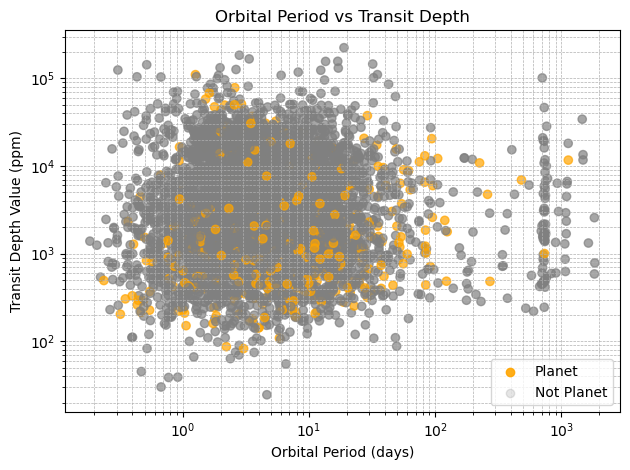

In [10]:
# Plotting the orbital period and transit depth to learn if there are any obvious coorelations

colors = LearningSet['is_planet'].map({True: 'orange', False: 'gray'})
# Setting the colors for each case.

plt.scatter(LearningSet['pl_orbper'], LearningSet['pl_trandep'],c=colors, alpha=0.7)
plt.scatter([], [], c='orange', label='Planet', alpha=0.9)
plt.scatter([], [], c='gray', label='Not Planet', alpha=0.2)
# Overplotting each case, changing the color and label. Planet detections have a higher alpha so they are more visually apparent.

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Orbital Period (days)')
plt.ylabel('Transit Depth Value (ppm)')
plt.title('Orbital Period vs Transit Depth')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()
# Other visualization improvements.

In [11]:
DTmodel = DecisionTreeClassifier(random_state = 3) #random_state = 3)
DTmodel.fit(Xtrain, ytrain)
# Setting up and fitting the model. Using the same random_state to control randomness.

DecisionTreeClassifier(random_state=3)

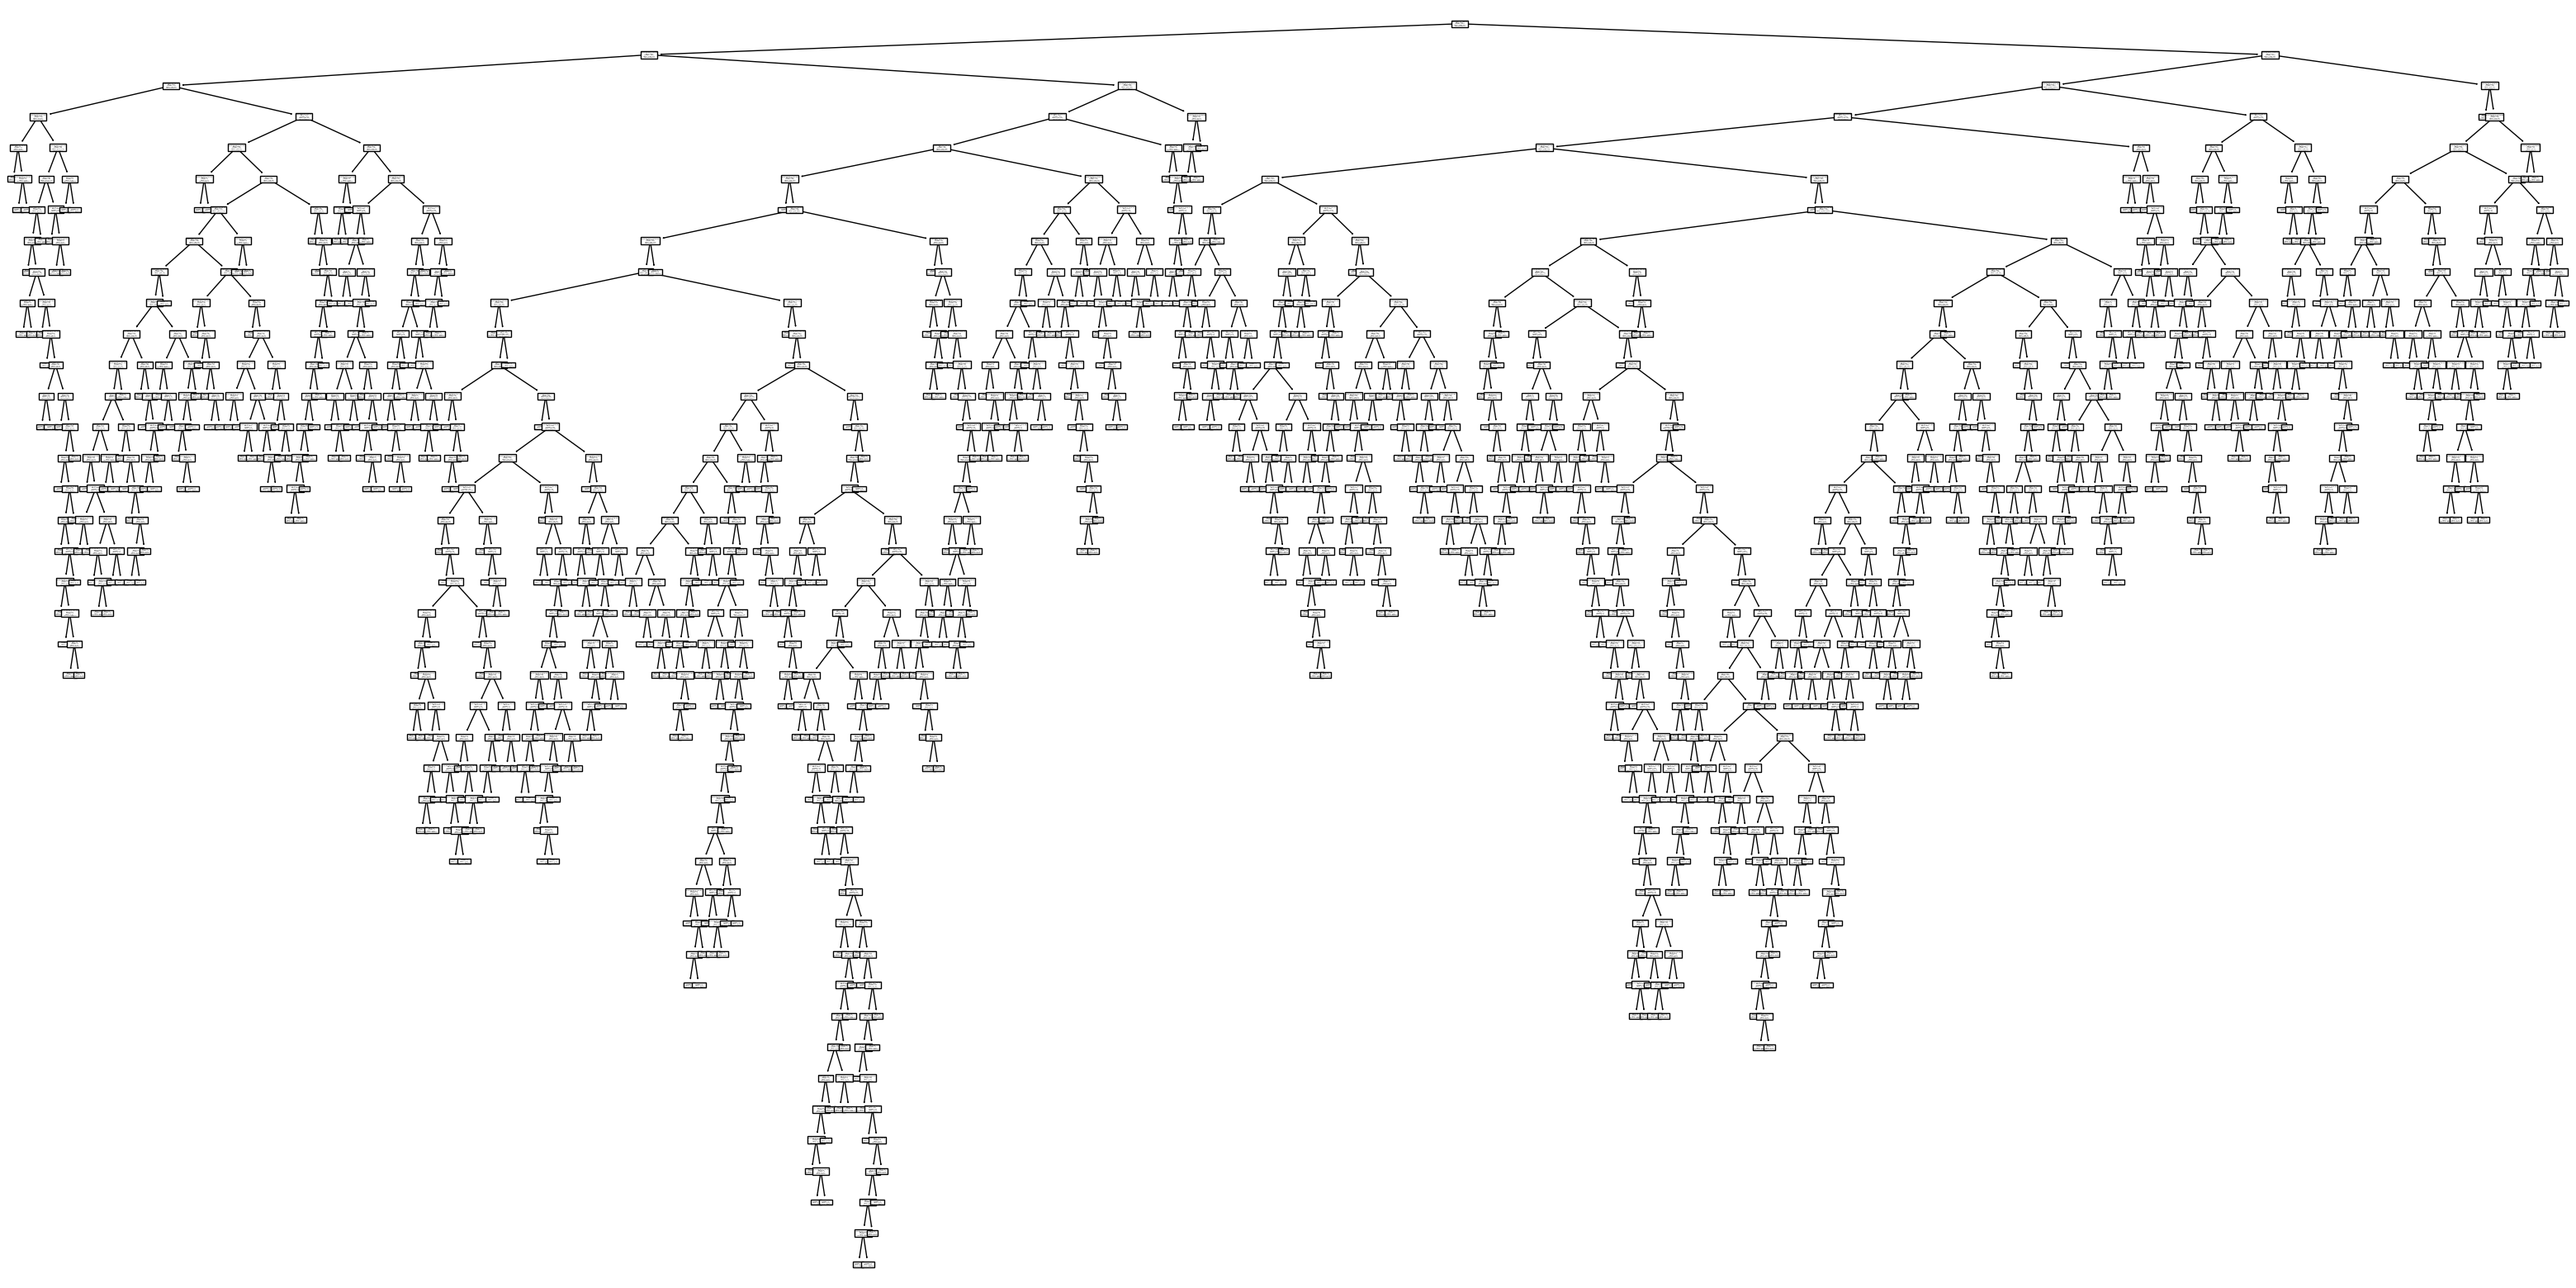

In [12]:
from sklearn import tree
plt.figure(figsize=(40,20)) 
_ = tree.plot_tree(DTmodel, feature_names = ['Orbital Period (d)', 'Transit Depth'], class_names = ['Detection','Non-Detection'])
# Plotting the decision tree to gain visual intuition.

In [13]:
y_DT_prediction = DTmodel.predict(Xtest) #Setting up our predicted values from the decision tree
print(y_DT_prediction) # Predicted is_planet testing set
print(sum(y_DT_prediction)) #Total number of predicted confirmed exoplanets in the testing set.
print(len(y_DT_prediction)-sum(y_DT_prediction)) # Total number of predicted non-detections in the testing set.
print(sum(ytest)) # The actual number of exoplanets in the testing set.

[ True False False ... False False  True]
180
1158
77


In [14]:
cm = metrics.confusion_matrix(ytest,DTmodel.predict(Xtest))
print(cm)
# Printing the confusion matrix

[[1093  168]
 [  65   12]]


In [15]:
# This function was taken from a class activity. This visually reproduces the above confusion matrix. 
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.

    Inputs
    cm: confusion matrix (2D numpy array)
    classes: list of class labels
    normalize: whether to normalize the matrix
    title: title of the plot
    cmap: color map for the plot
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    plt.figure(figsize=(7,6))
    print(cm)
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center", verticalalignment="center",
                 color="green" if i == j else "red", fontsize = 30)

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

Confusion matrix, without normalization
[[1093  168]
 [  65   12]]


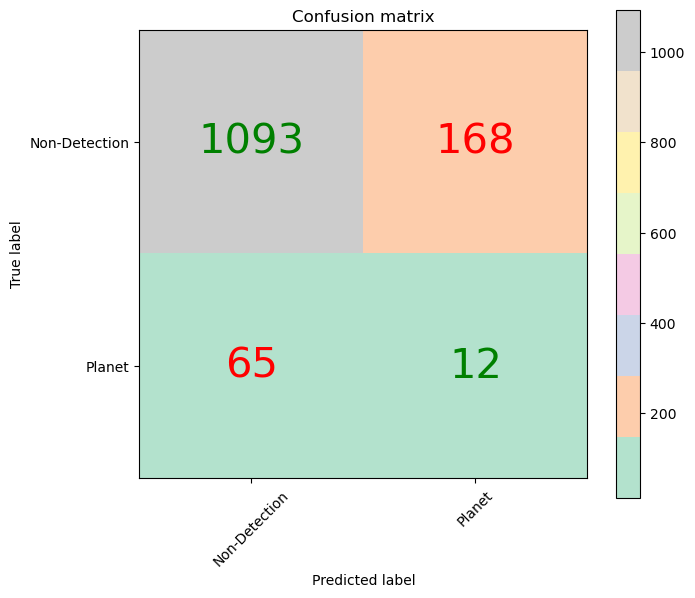

In [16]:
plot_confusion_matrix(cm, ['Non-Detection','Planet'], cmap = plt.cm.Pastel2)
# Plotting the confusion matrix.

In [17]:
print(metrics.accuracy_score(ytest, y_DT_prediction))
# Printing the accuracy score

0.8258594917787743


In [18]:
print(metrics.precision_score(ytest, y_DT_prediction))
# Printing the precision score

0.06666666666666667


In [19]:
print(metrics.recall_score(ytest, y_DT_prediction))
# Printing the recall score

0.15584415584415584


***Improved Attempts***

In [20]:
# Note: This cell's functions were created with the help of ChatGPT.

def evaluate_combinations_recall(df_candidates):

    # Define feature candidates and drop NaNs
    features = ['pl_orbper', 'pl_trandurh', 'pl_trandep', 'pl_rade', 'pl_eqt', 'st_dist']
    LearningSet = df_candidates[features + ['is_planet']].dropna()

    # Split into training and testing sets
    TrainSet = LearningSet.iloc[:5348, :]
    TestSet = LearningSet.iloc[5348:, :]

    # Target variables
    ytrain = TrainSet['is_planet']
    ytest = TestSet['is_planet']

    # Setting up our results array
    results = []

    # Iterate over all non-repeating combinations of 1 to 6 features
    for i in range(1, len(features)+1):
        for combo in itertools.combinations(features, i):
            # Note: The intertools module was a new discovery. 
            # itertools.combinations sets up every combination of specified values and returns it into the combo variable.
            # We take each combo and return into the training and testing set to perform our analysis
            Xtrain_improved = TrainSet[list(combo)]
            Xtest_improved = TestSet[list(combo)]

            # Set up, fit, and predict the detections
            DTmodel_imp = DecisionTreeClassifier(random_state=3)
            DTmodel_imp.fit(Xtrain_improved, ytrain)
            y_DT_prediction_imp = DTmodel_imp.predict(Xtest_improved)

            # Calculate the recall score, and add it to our results array.
            recall = metrics.recall_score(ytest, y_DT_prediction_imp)
            results.append((combo, recall))

    # Sort results by recall in descending order
    results_sorted = sorted(results, key=lambda x: x[1], reverse=True)

    # Convert to DataFrame for cleaner presentation
    results_df = pd.DataFrame(results_sorted, columns=['Feature Combination', 'Recall Score'])

    return results_df


In [21]:
# Finding our best recall combinations.
results_df = evaluate_combinations_recall(df_candidates)
print(results_df.head(10))

                                 Feature Combination  Recall Score
0  (pl_orbper, pl_trandurh, pl_trandep, pl_rade, ...      0.519481
1  (pl_orbper, pl_trandurh, pl_rade, pl_eqt, st_d...      0.480519
2              (pl_orbper, pl_rade, pl_eqt, st_dist)      0.467532
3                 (pl_trandurh, pl_trandep, st_dist)      0.441558
4  (pl_orbper, pl_trandep, pl_rade, pl_eqt, st_dist)      0.441558
5                      (pl_orbper, pl_rade, st_dist)      0.415584
6         (pl_orbper, pl_trandurh, pl_rade, st_dist)      0.415584
7                      (pl_trandep, pl_eqt, st_dist)      0.402597
8            (pl_trandurh, pl_rade, pl_eqt, st_dist)      0.402597
9                             (pl_trandurh, st_dist)      0.389610


In [22]:
# Out of curiosity: Lets try Accuracy and Precision
# Note: These functions are identical to the above Recall function, only changing the recall specific line.
# Once again, comments are redundant here.

def evaluate_combinations_accuracy(df_candidates):

    features = ['pl_orbper', 'pl_trandurh', 'pl_trandep', 'pl_rade', 'pl_eqt', 'st_dist']
    LearningSet = df_candidates[features + ['is_planet']].dropna()

    TrainSet = LearningSet.iloc[:5348, :]
    TestSet = LearningSet.iloc[5348:, :]

    ytrain = TrainSet['is_planet']
    ytest = TestSet['is_planet']

    results = []

    # Iterate over all non-repeating combinations of 1 to 6 features
    for i in range(1, len(features)+1):
        for combo in itertools.combinations(features, i):
            Xtrain_improved = TrainSet[list(combo)]
            Xtest_improved = TestSet[list(combo)]

            DTmodel_imp = DecisionTreeClassifier(random_state=3)
            DTmodel_imp.fit(Xtrain_improved, ytrain)
            y_DT_prediction_imp = DTmodel_imp.predict(Xtest_improved)

            accuracy = metrics.accuracy_score(ytest, y_DT_prediction_imp)
            results.append((combo, accuracy))

    results_sorted = sorted(results, key=lambda x: x[1], reverse=True)

    results_df = pd.DataFrame(results_sorted, columns=['Feature Combination', 'Accuracy Score'])

    return results_df

In [23]:
results_df_accuracy = evaluate_combinations_accuracy(df_candidates)
print(results_df_accuracy.head(10))

                                 Feature Combination  Accuracy Score
0  (pl_orbper, pl_trandep, pl_rade, pl_eqt, st_dist)        0.899103
1                 (pl_trandurh, pl_trandep, st_dist)        0.897608
2                         (pl_rade, pl_eqt, st_dist)        0.897608
3                             (pl_trandurh, st_dist)        0.896861
4                                 (pl_rade, st_dist)        0.895366
5      (pl_orbper, pl_trandurh, pl_trandep, st_dist)        0.895366
6             (pl_trandep, pl_rade, pl_eqt, st_dist)        0.895366
7  (pl_orbper, pl_trandurh, pl_trandep, pl_eqt, s...        0.895366
8  (pl_orbper, pl_trandurh, pl_rade, pl_eqt, st_d...        0.893871
9                    (pl_trandurh, pl_rade, st_dist)        0.892377


In [24]:
def evaluate_combinations_precision(df_candidates):

    features = ['pl_orbper', 'pl_trandurh', 'pl_trandep', 'pl_rade', 'pl_eqt', 'st_dist']
    LearningSet = df_candidates[features + ['is_planet']].dropna()

    TrainSet = LearningSet.iloc[:5348, :]
    TestSet = LearningSet.iloc[5348:, :]

    ytrain = TrainSet['is_planet']
    ytest = TestSet['is_planet']

    results = []

    # Iterate over all non-repeating combinations of 1 to 6 features
    for i in range(1, len(features)+1):
        for combo in itertools.combinations(features, i):
            Xtrain_improved = TrainSet[list(combo)]
            Xtest_improved = TestSet[list(combo)]

            DTmodel_imp = DecisionTreeClassifier(random_state=3)
            DTmodel_imp.fit(Xtrain_improved, ytrain)
            y_DT_prediction_imp = DTmodel_imp.predict(Xtest_improved)

            precision = metrics.precision_score(ytest, y_DT_prediction_imp)
            results.append((combo, precision))

    results_sorted = sorted(results, key=lambda x: x[1], reverse=True)

    results_df_precision = pd.DataFrame(results_sorted, columns=['Feature Combination', 'Precision Score'])

    return results_df_precision

In [25]:
results_df_precision = evaluate_combinations_precision(df_candidates)
print(results_df_precision.head(10))

                                 Feature Combination  Precision Score
0  (pl_orbper, pl_trandurh, pl_trandep, pl_rade, ...         0.270270
1  (pl_orbper, pl_trandep, pl_rade, pl_eqt, st_dist)         0.269841
2  (pl_orbper, pl_trandurh, pl_rade, pl_eqt, st_d...         0.266187
3                 (pl_trandurh, pl_trandep, st_dist)         0.265625
4              (pl_orbper, pl_rade, pl_eqt, st_dist)         0.255319
5                             (pl_trandurh, st_dist)         0.247934
6            (pl_trandurh, pl_rade, pl_eqt, st_dist)         0.238462
7         (pl_orbper, pl_trandurh, pl_rade, st_dist)         0.237037
8  (pl_orbper, pl_trandurh, pl_trandep, pl_eqt, s...         0.235294
9        (pl_trandurh, pl_trandep, pl_rade, st_dist)         0.234375


Confusion matrix, without normalization
[[1153  108]
 [  37   40]]


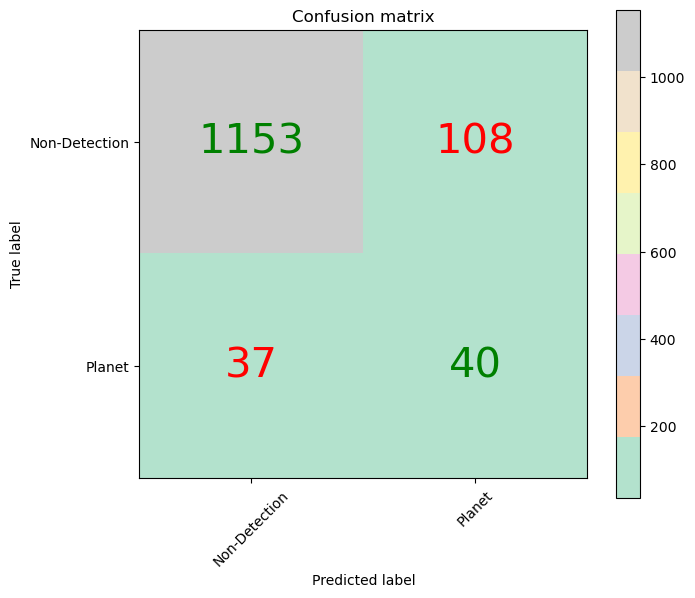

In [26]:
# Plotting the confusion matrix of our best model with all specified parameters.
# This process is repeated from above.

Xtrain_improved = TrainSet[['pl_orbper', 'pl_trandurh', 'pl_trandep', 'pl_rade', 'pl_eqt', 'st_dist']]
Xtest_improved = TestSet[['pl_orbper', 'pl_trandurh', 'pl_trandep', 'pl_rade', 'pl_eqt', 'st_dist']]

DTmodel_imp = DecisionTreeClassifier(random_state = 3) #random_state = 3)
DTmodel_imp.fit(Xtrain_improved, ytrain)

y_DT_prediction_imp = DTmodel_imp.predict(Xtest_improved)

cm = metrics.confusion_matrix(ytest,y_DT_prediction_imp)
plot_confusion_matrix(cm, ['Non-Detection','Planet'], cmap = plt.cm.Pastel2)